In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src.metrics import mae, rmse

HORIZON = 72
wf = pd.read_csv(ROOT / "results" / f"walk_forward_h{HORIZON}.csv",
                 index_col=0, parse_dates=True)

MODELS = ["baseline", "Linear regression", "Decision tree", "SVR"]
COLOURS = {"baseline": "#898781", "Linear regression": "#eb6834",
           "Decision tree": "#1baf7a", "SVR": "#2a78d6"}
print(wf.shape, wf.index.min(), "to", wf.index.max())

(8616, 6) 2025-10-01 00:00:00 to 2026-09-24 23:00:00


In [2]:
base_mae = mae(wf["actual"], wf["baseline"])
rows = []
for m in MODELS:
    rows.append({
        "Model": m,
        "MAE ($/MWh)": mae(wf["actual"], wf[m]),
        "RMSE ($/MWh)": rmse(wf["actual"], wf[m]),
        "Bias ($/MWh)": (wf[m] - wf["actual"]).mean(),
        "MAE better than baseline (%)": 100 * (1 - mae(wf["actual"], wf[m]) / base_mae),
    })
table = pd.DataFrame(rows).set_index("Model").round(2)
table.to_csv(ROOT / "results" / f"model_comparison_h{HORIZON}.csv")
table

,MAE ($/MWh),RMSE ($/MWh),Bias ($/MWh),MAE better than baseline (%)
Model,,,,
baseline,53.78,91.00,0.07,0.00
Linear regression,45.04,69.43,18.51,16.26
Decision tree,43.31,115.69,27.68,19.46
SVR,31.72,56.09,15.65,41.03


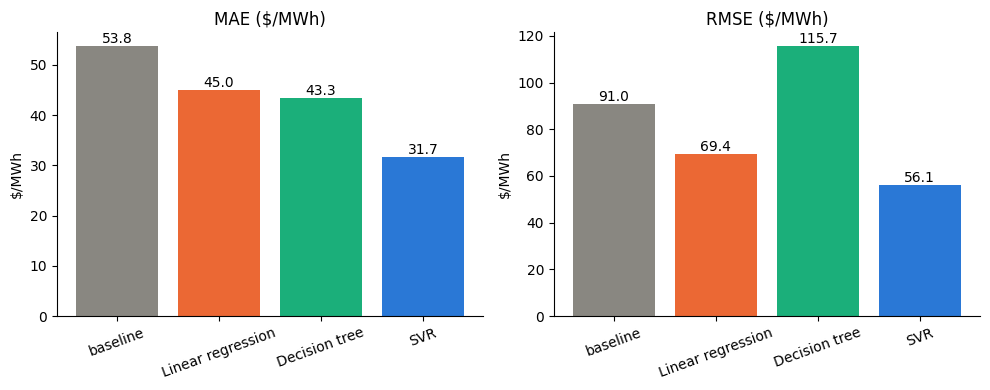

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ["MAE ($/MWh)", "RMSE ($/MWh)"]):
    bars = ax.bar(table.index, table[col], color=[COLOURS[m] for m in table.index])
    ax.set_title(col)
    ax.set_ylabel("$/MWh")
    ax.tick_params(axis="x", rotation=20)
    for b, v in zip(bars, table[col]):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.1f}", ha="center", va="bottom")
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(ROOT / "results" / "fig_mae_rmse_h72.png", dpi=150)
plt.show()

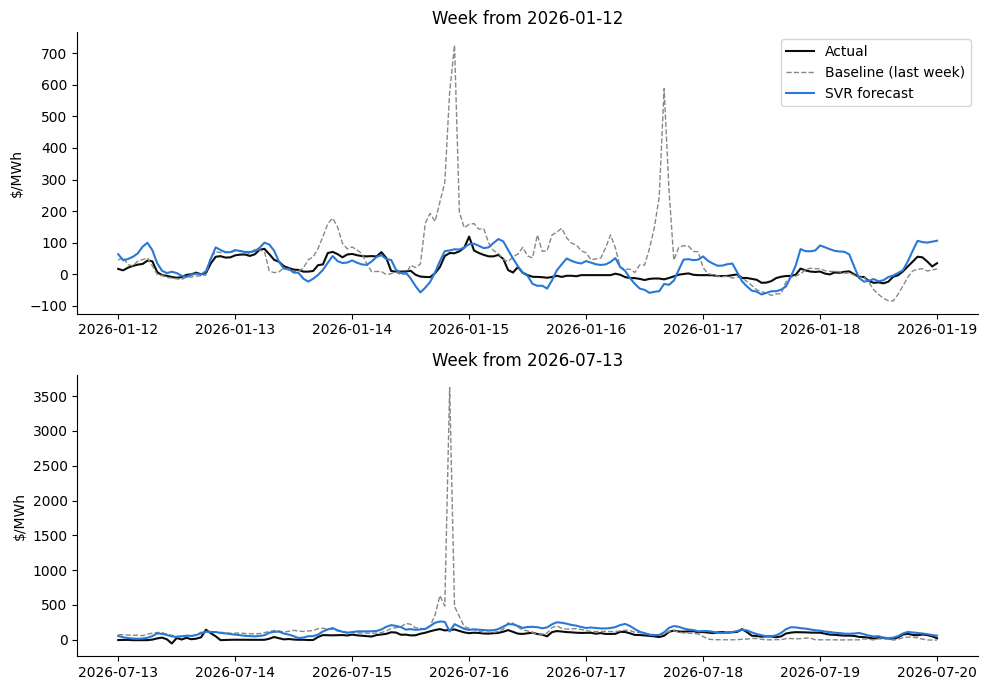

In [4]:
def plot_week(ax, start):
    w = wf.loc[start: pd.Timestamp(start) + pd.Timedelta(days=7)]
    ax.plot(w.index, w["actual"], color="#0b0b0b", lw=1.5, label="Actual")
    ax.plot(w.index, w["baseline"], color=COLOURS["baseline"], lw=1, ls="--", label="Baseline (last week)")
    ax.plot(w.index, w["SVR"], color=COLOURS["SVR"], lw=1.5, label="SVR forecast")
    ax.set_ylabel("$/MWh")
    ax.set_title(f"Week from {start}")
    ax.spines[["top", "right"]].set_visible(False)

fig, axes = plt.subplots(2, 1, figsize=(10, 7))
plot_week(axes[0], "2026-01-12")   # summer
plot_week(axes[1], "2026-07-13")   # winter
axes[0].legend(loc="upper right")
plt.tight_layout()
plt.savefig(ROOT / "results" / "fig_sample_weeks_h72.png", dpi=150)
plt.show()

In [5]:
err = (wf[["baseline", "SVR"]].sub(wf["actual"], axis=0)).abs()
by_month = err.groupby(err.index.to_period("M")).mean().round(1)
by_month.columns = ["Baseline MAE", "SVR MAE"]
by_month

,Baseline MAE,SVR MAE
hour_end,,
2025-10,62.3,30.9
2025-11,51.4,28.7
2025-12,49.6,27.1
2026-01,54.1,37.1
2026-02,49.9,29.7
2026-03,48.2,24.8
2026-04,39.5,24.2
2026-05,45.1,36.7
2026-06,63.2,29.9


In [6]:
out = pd.DataFrame({
    "price_actual_mwh": wf["actual"],
    "price_forecast_mwh": wf["SVR"],
    "price_baseline_mwh": wf["baseline"],
})
out.index.name = "timestamp"
assert out.notna().all().all() and out.index.is_unique
out.to_csv(ROOT / "results" / "forecasts.csv")
print(out.shape)
out.head()

(8616, 3)


,price_actual_mwh,price_forecast_mwh,price_baseline_mwh
timestamp,,,
2025-10-01 00:00:00,5.950833,82.051319,83.734167
2025-10-01 01:00:00,8.121667,54.219931,36.173333
2025-10-01 02:00:00,1.061667,41.537018,19.843333
2025-10-01 03:00:00,-9.033333,35.150817,14.537500
2025-10-01 04:00:00,-10.000000,32.595286,6.585833


DRAFT: Support vector regression achieved the lowest errors, with a mean absolute error of $31.72/MWh and a root mean square error of $56.09/MWh, which are 41% and 38% below the same-hour-last-week baseline respectively. Its ability to fit non-linear relationships between weather, demand, calendar effects and price allowed it to capture patterns that a linear model cannot. The decision tree improved on the baseline in mean absolute error but exceeded it in root mean square error ($115.69/MWh), because its piecewise-constant predictions produce large misses when a price spike is mispredicted, and squaring amplifies those misses. Errors were largest in the winter months, when price spikes are most frequent.

In [7]:
combo = {}
for h in [72, 96, 120]:
    d = pd.read_csv(ROOT / "results" / f"walk_forward_h{h}.csv", index_col=0, parse_dates=True)
    combo[f"{h} h"] = {"MAE": mae(d["actual"], d["SVR"]), "RMSE": rmse(d["actual"], d["SVR"])}
pd.DataFrame(combo).T.round(2)

,MAE,RMSE
72 h,31.72,56.09
96 h,32.27,56.47
120 h,32.43,56.59
